#Loan Default Risk Prediction Using Business Analytics and Machine Learning

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/archive (3).zip")

# Basic information
print("Shape:", df.shape)

# First 5 rows
display(df.head())

# Column names and data types
display(df.dtypes)
# Check default_flag distribution
print("Default Flag Distribution:")
print(df["default_flag"].value_counts())

print("\nDefault Flag Percentage:")
print(df["default_flag"].value_counts(normalize=True) * 100)

# Check default_risk_score
print("\nDefault Risk Score:")
display(df["default_risk_score"].describe())
df = df.drop(columns=["default_risk_score", "applicant_id"])

print("New shape:", df.shape)
display(df.head())

Shape: (25000, 22)


,applicant_id,age,gender,marital_status,city_tier,state,employment_type,bank_account_vintage_years,monthly_income_inr,existing_loans_count,...,num_credit_inquiries_last_6m,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,loan_purpose,collateral_provided,cibil_score,interest_rate_offered_pct,default_risk_score,default_flag
0,APP106868,22,Male,Single,Tier 3,Haryana,Salaried - PSU,0.5,12000,1,...,2.0,0,149000,48,Personal Expense,No,649,24.84,1.67,0
1,APP124016,35,Female,Divorced,Tier 2,Gujarat,Salaried - Private,0.5,32500,3,...,0.0,1,156000,60,Personal Expense,No,538,25.25,4.47,0
2,APP109668,41,Male,Married,Tier 2,Uttar Pradesh,Salaried - Government,2.8,52500,0,...,0.0,0,70000,36,Wedding,No,636,20.46,0.19,0
3,APP113640,29,Female,Married,Tier 2,Kerala,Salaried - PSU,0.7,15500,1,...,0.0,1,108000,48,Education,No,721,15.27,0.26,0
4,APP114018,31,Male,Married,Tier 1,Punjab,Self-Employed Professional,4.7,269600,2,...,0.0,2,466000,24,Education,No,586,25.52,2.10,0


,0
applicant_id,object
age,int64
gender,object
marital_status,object
city_tier,object
state,object
employment_type,object
bank_account_vintage_years,float64
monthly_income_inr,int64
existing_loans_count,int64


Default Flag Distribution:
default_flag
0    23465
1     1535
Name: count, dtype: int64

Default Flag Percentage:
default_flag
0    93.86
1     6.14
Name: proportion, dtype: float64

Default Risk Score:


,default_risk_score
count,25000.000000
mean,6.271094
std,11.938843
min,0.000000
25%,0.530000
50%,1.770000
75%,5.852500
max,99.080000


New shape: (25000, 20)


,age,gender,marital_status,city_tier,state,employment_type,bank_account_vintage_years,monthly_income_inr,existing_loans_count,existing_emi_monthly_inr,credit_utilization_ratio_pct,num_credit_inquiries_last_6m,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,loan_purpose,collateral_provided,cibil_score,interest_rate_offered_pct,default_flag
0,22,Male,Single,Tier 3,Haryana,Salaried - PSU,0.5,12000,1,1700.0,31.4,2.0,0,149000,48,Personal Expense,No,649,24.84,0
1,35,Female,Divorced,Tier 2,Gujarat,Salaried - Private,0.5,32500,3,11500.0,47.6,0.0,1,156000,60,Personal Expense,No,538,25.25,0
2,41,Male,Married,Tier 2,Uttar Pradesh,Salaried - Government,2.8,52500,0,6000.0,51.8,0.0,0,70000,36,Wedding,No,636,20.46,0
3,29,Female,Married,Tier 2,Kerala,Salaried - PSU,0.7,15500,1,1900.0,12.2,0.0,1,108000,48,Education,No,721,15.27,0
4,31,Male,Married,Tier 1,Punjab,Self-Employed Professional,4.7,269600,2,50800.0,50.3,0.0,2,466000,24,Education,No,586,25.52,0


In [ ]:
# Check missing values
missing = df.isnull().sum()

# Show only columns that have missing values
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values:")
display(missing)

# Missing percentage
missing_percentage = (df.isnull().sum() / len(df) * 100)
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("\nMissing percentage:")
display(missing_percentage)

Missing values:


,0
existing_emi_monthly_inr,500
bank_account_vintage_years,375
num_credit_inquiries_last_6m,250



Missing percentage:


,0
existing_emi_monthly_inr,2.0
bank_account_vintage_years,1.5
num_credit_inquiries_last_6m,1.0


In [ ]:
# Number of rows before cleaning
print("Rows before removing missing values:", len(df))

# Remove rows containing missing values
df_clean = df.dropna()

# Number of rows after cleaning
print("Rows after removing missing values:", len(df_clean))

# Number of rows removed
print("Rows removed:", len(df) - len(df_clean))

Rows before removing missing values: 25000
Rows after removing missing values: 23890
Rows removed: 1110


In [ ]:
# Verify that no missing values remain
print("Total missing values after cleaning:",
      df_clean.isnull().sum().sum())

Total missing values after cleaning: 0


In [ ]:
# Check duplicate rows
duplicates = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# Check numerical columns
numeric_cols = df_clean.select_dtypes(include="number").columns

display(df_clean[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,23890.0,35.321264,8.549108,21.00,29.00,35.00,41.00,65.0
bank_account_vintage_years,23890.0,4.000385,3.895201,0.50,1.10,2.80,5.50,25.0
monthly_income_inr,23890.0,54848.685643,38306.939407,12000.00,29500.00,45100.00,68700.00,727000.0
existing_loans_count,23890.0,1.105107,1.052180,0.00,0.00,1.00,2.00,6.0
existing_emi_monthly_inr,23890.0,11729.740477,10334.772077,0.00,5100.00,9000.00,15100.00,202300.0
credit_utilization_ratio_pct,23890.0,41.542750,19.779344,0.00,27.70,41.30,55.00,100.0
num_credit_inquiries_last_6m,23890.0,1.300460,1.136343,0.00,0.00,1.00,2.00,9.0
late_payments_last_12m,23890.0,1.443324,1.269360,0.00,0.00,1.00,2.00,8.0
loan_amount_requested_inr,23890.0,158347.886145,104144.881671,25000.00,88000.00,133000.00,199000.00,1519000.0
loan_tenure_months,23890.0,42.430975,19.206254,12.00,24.00,36.00,60.00,84.0


#Descriptive Analysis

In [ ]:
# Calculate IQR-based outliers for numerical variables

numeric_cols = df_clean.select_dtypes(include="number").columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df_clean[col] < lower_bound) |
                (df_clean[col] > upper_bound)).sum()

    outlier_summary.append({
        "Variable": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outliers,
        "Outlier %": round(outliers / len(df_clean) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df.sort_values("Outliers", ascending=False))

,Variable,Lower Bound,Upper Bound,Outliers,Outlier %
12,default_flag,0.00,0.00,1463,6.12
4,existing_emi_monthly_inr,-9900.00,30100.00,1256,5.26
1,bank_account_vintage_years,-5.50,12.10,1093,4.58
2,monthly_income_inr,-29300.00,127500.00,1072,4.49
8,loan_amount_requested_inr,-78500.00,365500.00,1071,4.48
10,cibil_score,446.50,786.50,174,0.73
7,late_payments_last_12m,-3.00,5.00,146,0.61
5,credit_utilization_ratio_pct,-13.25,95.95,90,0.38
0,age,11.00,59.00,77,0.32
6,num_credit_inquiries_last_6m,-3.00,5.00,54,0.23


In [ ]:
# Inspect extreme values

print("Highest monthly incomes:")
display(
    df_clean[["age", "monthly_income_inr", "default_flag"]]
    .sort_values("monthly_income_inr", ascending=False)
    .head(10)
)

print("\nHighest existing EMI:")
display(
    df_clean[["monthly_income_inr", "existing_emi_monthly_inr", "default_flag"]]
    .sort_values("existing_emi_monthly_inr", ascending=False)
    .head(10)
)

print("\nHighest loan amounts:")
display(
    df_clean[["monthly_income_inr", "loan_amount_requested_inr", "default_flag"]]
    .sort_values("loan_amount_requested_inr", ascending=False)
    .head(10)
)
df_clean = df_clean.copy()

df_clean["emi_income_ratio"] = (
    df_clean["existing_emi_monthly_inr"] /
    df_clean["monthly_income_inr"]
) * 100

df_clean["loan_income_ratio"] = (
    df_clean["loan_amount_requested_inr"] /
    (df_clean["monthly_income_inr"] * 12)
)

Highest monthly incomes:


,age,monthly_income_inr,default_flag
7183,30,727000,0
15513,45,588300,0
9287,26,574500,0
15042,51,517300,0
6990,44,435800,1
9403,37,435100,0
11694,31,424400,0
11940,52,417100,0
15812,32,383400,0
430,45,382500,0



Highest existing EMI:


,monthly_income_inr,existing_emi_monthly_inr,default_flag
7183,727000,202300.0,0
9287,574500,158900.0,0
9403,435100,141400.0,0
23437,327800,131500.0,1
7111,365000,126600.0,0
22737,327900,124100.0,0
21959,331400,122000.0,0
7110,312400,121200.0,1
13670,297100,120300.0,0
838,344900,117500.0,0



Highest loan amounts:


,monthly_income_inr,loan_amount_requested_inr,default_flag
23124,21700,1519000,1
4856,72700,1372000,0
365,40900,1322000,0
15443,41000,1233000,1
22076,17100,1233000,1
21600,111700,1206000,0
5980,19900,1181000,1
16517,101800,1097000,0
15512,53600,1089000,0
18172,18000,1016000,1


In [ ]:
# Identify categorical columns
categorical_cols = df_clean.select_dtypes(include="object").columns

print("Categorical columns:")
print(list(categorical_cols))

# Display unique values for each categorical column
for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())

Categorical columns:
['gender', 'marital_status', 'city_tier', 'state', 'employment_type', 'loan_purpose', 'collateral_provided']

gender:
gender
Male      14255
Female     9178
Other       457
Name: count, dtype: int64

marital_status:
marital_status
Married     13917
Single       7549
Divorced     1456
Widowed       968
Name: count, dtype: int64

city_tier:
city_tier
Tier 1    9535
Tier 2    9103
Tier 3    5252
Name: count, dtype: int64

state:
state
Gujarat           1676
Andhra Pradesh    1658
Tamil Nadu        1656
Rajasthan         1650
Telangana         1616
Kerala            1613
Uttar Pradesh     1598
Karnataka         1596
Madhya Pradesh    1576
West Bengal       1575
Maharashtra       1557
Bihar             1554
Delhi NCR         1537
Punjab            1520
Haryana           1508
Name: count, dtype: int64

employment_type:
employment_type
Salaried - Private            10730
Salaried - Government          3650
Self-Employed Professional     3587
Business Owner                

In [ ]:
# Descriptive statistics of cleaned numerical variables

display(
    df_clean.describe().T.round(2)
)
# Default rate
default_rate = df_clean["default_flag"].mean() * 100

print(f"Overall default rate: {default_rate:.2f}%")
# Default count and percentage
default_summary = df_clean["default_flag"].value_counts().to_frame("Count")
default_summary["Percentage"] = (
    default_summary["Count"] / len(df_clean) * 100
)

display(default_summary)

,count,mean,std,min,25%,50%,75%,max
age,23890.0,35.32,8.55,21.00,29.00,35.00,41.00,65.00
bank_account_vintage_years,23890.0,4.00,3.90,0.50,1.10,2.80,5.50,25.00
monthly_income_inr,23890.0,54848.69,38306.94,12000.00,29500.00,45100.00,68700.00,727000.00
existing_loans_count,23890.0,1.11,1.05,0.00,0.00,1.00,2.00,6.00
existing_emi_monthly_inr,23890.0,11729.74,10334.77,0.00,5100.00,9000.00,15100.00,202300.00
credit_utilization_ratio_pct,23890.0,41.54,19.78,0.00,27.70,41.30,55.00,100.00
num_credit_inquiries_last_6m,23890.0,1.30,1.14,0.00,0.00,1.00,2.00,9.00
late_payments_last_12m,23890.0,1.44,1.27,0.00,0.00,1.00,2.00,8.00
loan_amount_requested_inr,23890.0,158347.89,104144.88,25000.00,88000.00,133000.00,199000.00,1519000.00
loan_tenure_months,23890.0,42.43,19.21,12.00,24.00,36.00,60.00,84.00


Overall default rate: 6.12%


,Count,Percentage
default_flag,,
0,22427,93.876099
1,1463,6.123901


In [ ]:
# Compare numerical variables between defaulters and non-defaulters

comparison = df_clean.groupby("default_flag")[
    [
        "age",
        "monthly_income_inr",
        "existing_loans_count",
        "existing_emi_monthly_inr",
        "credit_utilization_ratio_pct",
        "num_credit_inquiries_last_6m",
        "late_payments_last_12m",
        "loan_amount_requested_inr",
        "loan_tenure_months",
        "cibil_score",
        "interest_rate_offered_pct",
        "emi_income_ratio",
        "loan_income_ratio"
    ]
].mean().T

comparison.columns = ["Non-Defaulters", "Defaulters"]

display(comparison.round(2))

,Non-Defaulters,Defaulters
age,35.35,34.84
monthly_income_inr,55167.64,49959.33
existing_loans_count,1.08,1.44
existing_emi_monthly_inr,11570.17,14175.94
credit_utilization_ratio_pct,40.61,55.80
num_credit_inquiries_last_6m,1.28,1.55
late_payments_last_12m,1.37,2.64
loan_amount_requested_inr,156749.28,182853.73
loan_tenure_months,42.41,42.73
cibil_score,620.40,538.38


#Data Visualization

<Figure size 800x500 with 0 Axes>

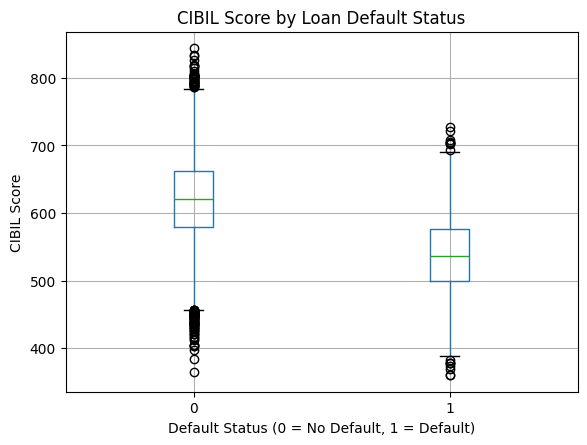

In [ ]:
#Visualisation 1- CIBIL score vs default status
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="cibil_score",
    by="default_flag"
)

plt.title("CIBIL Score by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status (0 = No Default, 1 = Default)")
plt.ylabel("CIBIL Score")
plt.show()

<Figure size 800x500 with 0 Axes>

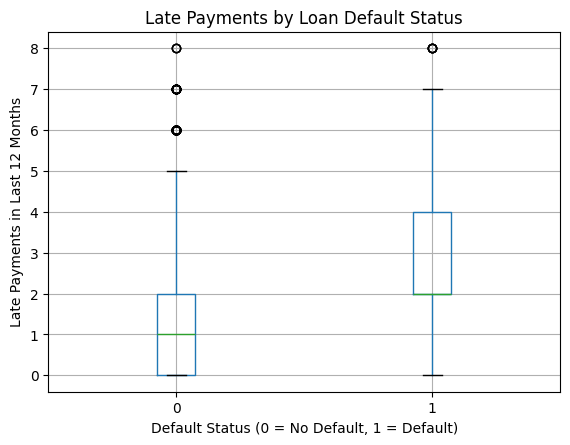

In [ ]:
#Visualization 2 — Late Payments vs Default
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="late_payments_last_12m",
    by="default_flag"
)

plt.title("Late Payments by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status (0 = No Default, 1 = Default)")
plt.ylabel("Late Payments in Last 12 Months")
plt.show()

<Figure size 800x500 with 0 Axes>

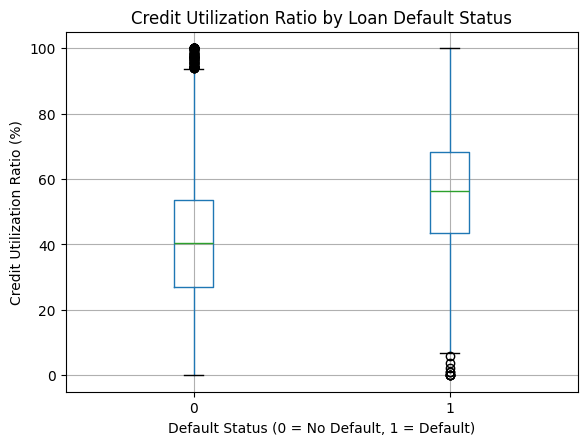

In [ ]:
#Visualization 3 — Credit Utilization
plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="credit_utilization_ratio_pct",
    by="default_flag"
)

plt.title("Credit Utilization Ratio by Loan Default Status")
plt.suptitle("")
plt.xlabel("Default Status (0 = No Default, 1 = Default)")
plt.ylabel("Credit Utilization Ratio (%)")
plt.show()

In [ ]:
Default rate by Employment Type
employment_default = (
    df_clean.groupby("employment_type")["default_flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(employment_default)

employment_type
Business Owner                7.412627
Salaried - Government         6.657534
Salaried - Private            5.824790
Salaried - PSU                5.600000
Self-Employed Professional    5.547812
Name: default_flag, dtype: float64


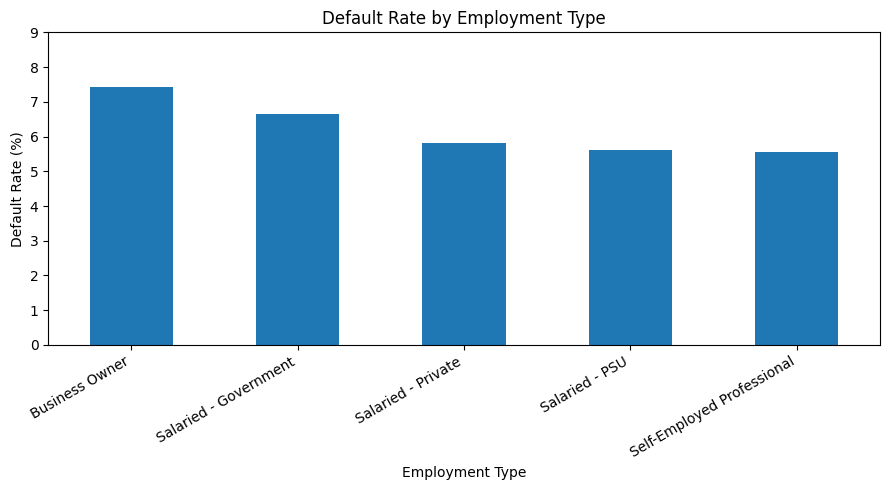

In [ ]:
# Visualization 4 - Default Rate by Employment Type

plt.figure(figsize=(9, 5))

employment_default.plot(kind="bar")

plt.title("Default Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 9)

plt.tight_layout()
plt.show()

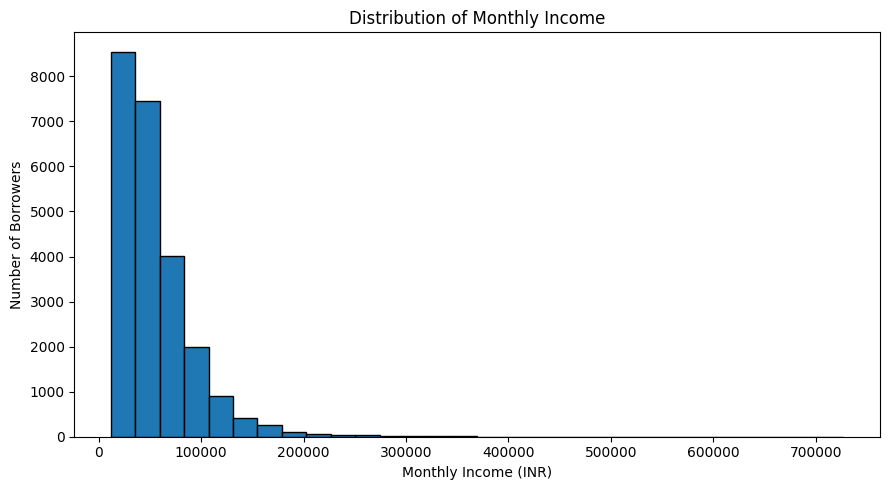

In [ ]:
# Visualization 5 - Monthly Income Distribution

plt.figure(figsize=(9, 5))

plt.hist(
    df_clean["monthly_income_inr"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income (INR)")
plt.ylabel("Number of Borrowers")

plt.tight_layout()
plt.show()

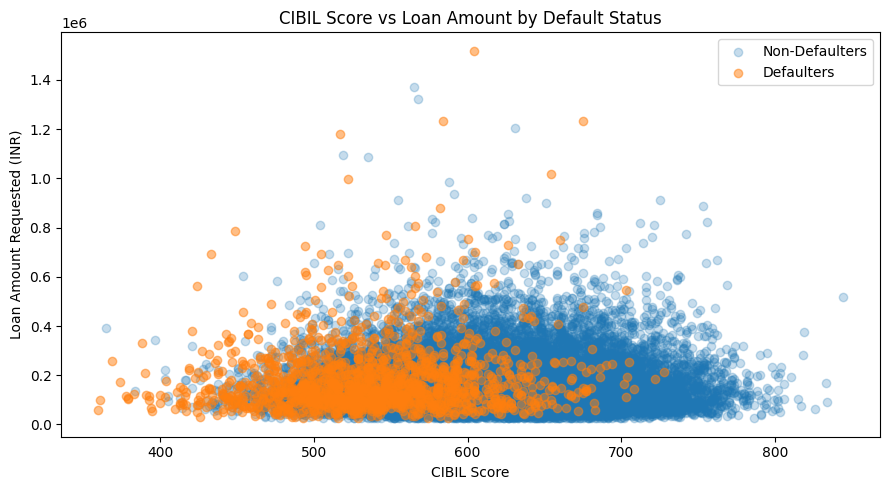

In [ ]:
# Visualization 6 - CIBIL Score vs Loan Amount by Default Status

plt.figure(figsize=(9, 5))

non_default = df_clean[df_clean["default_flag"] == 0]
default = df_clean[df_clean["default_flag"] == 1]

plt.scatter(
    non_default["cibil_score"],
    non_default["loan_amount_requested_inr"],
    alpha=0.25,
    label="Non-Defaulters"
)

plt.scatter(
    default["cibil_score"],
    default["loan_amount_requested_inr"],
    alpha=0.5,
    label="Defaulters"
)

plt.title("CIBIL Score vs Loan Amount by Default Status")
plt.xlabel("CIBIL Score")
plt.ylabel("Loan Amount Requested (INR)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Visualization 7 - Default status by collateral

collateral_default = pd.crosstab(
    df_clean["collateral_provided"],
    df_clean["default_flag"],
    normalize="index"
) * 100

print(collateral_default.round(2))

default_flag             0     1
collateral_provided             
No                   93.16  6.84
Yes                  96.43  3.57


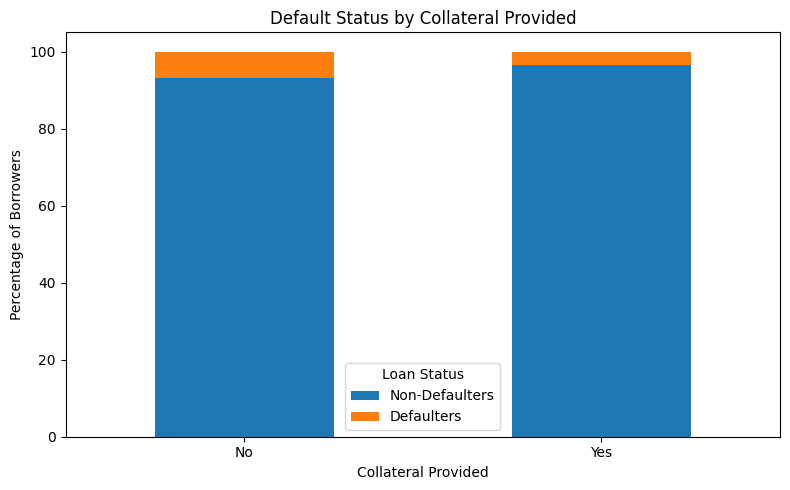

In [ ]:
# Visualization 7 - Default Status by Collateral

collateral_default.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Default Status by Collateral Provided")
plt.xlabel("Collateral Provided")
plt.ylabel("Percentage of Borrowers")
plt.xticks(rotation=0)
plt.legend(
    ["Non-Defaulters", "Defaulters"],
    title="Loan Status"
)

plt.tight_layout()
plt.show()

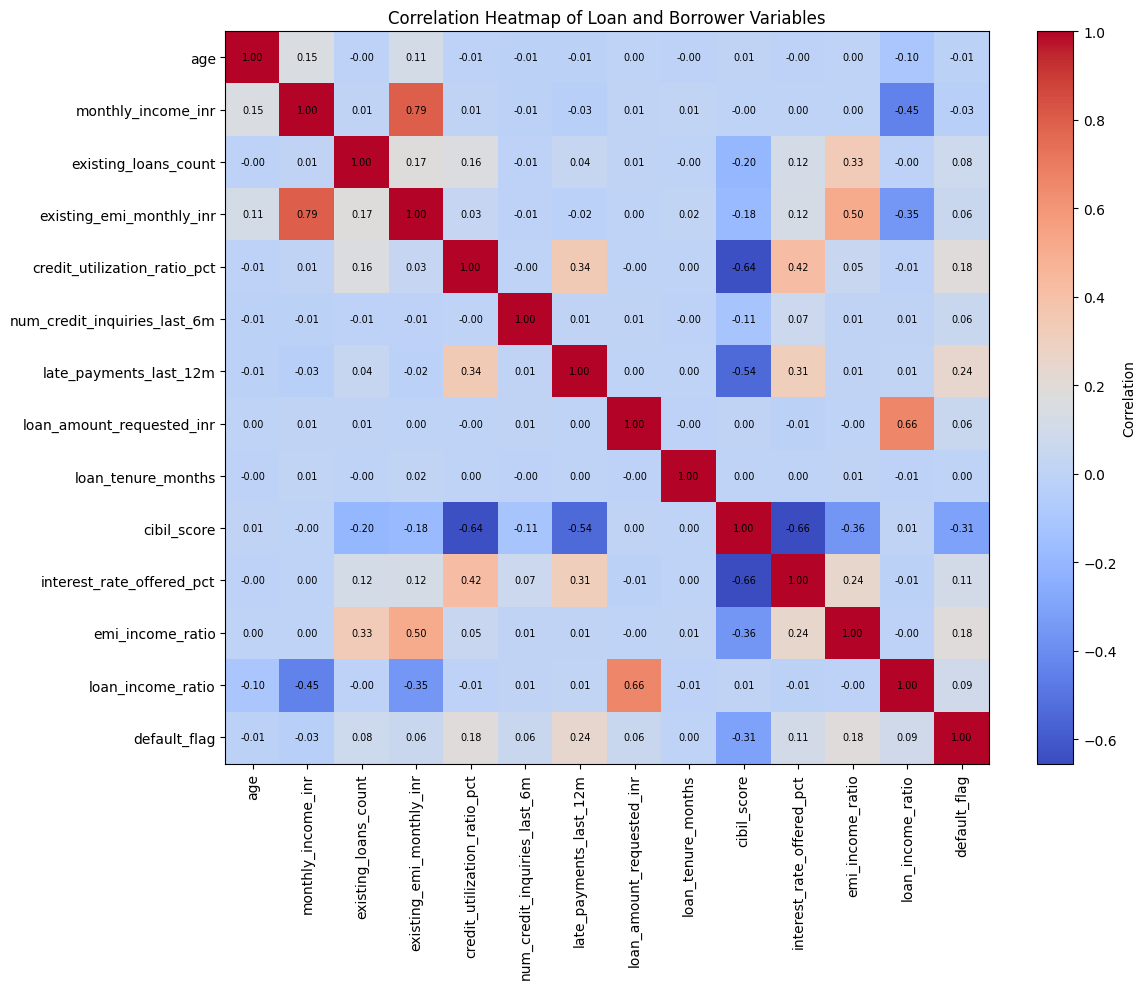

In [ ]:
# Visualization 8 - Correlation Heatmap

import numpy as np
import matplotlib.pyplot as plt

# Select numerical variables
corr_cols = [
    "age",
    "monthly_income_inr",
    "existing_loans_count",
    "existing_emi_monthly_inr",
    "credit_utilization_ratio_pct",
    "num_credit_inquiries_last_6m",
    "late_payments_last_12m",
    "loan_amount_requested_inr",
    "loan_tenure_months",
    "cibil_score",
    "interest_rate_offered_pct",
    "emi_income_ratio",
    "loan_income_ratio",
    "default_flag"
]

corr = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 10))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_cols)),
    corr_cols,
    rotation=90
)

plt.yticks(
    range(len(corr_cols)),
    corr_cols
)

# Add correlation values inside cells
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.title("Correlation Heatmap of Loan and Borrower Variables")
plt.tight_layout()
plt.show()

#Predictive Analysis & Machine Learning

In [ ]:
# Step 1: Define predictors and target

# Target variable
y = df_clean["default_flag"]

# Remove target from predictors
X = df_clean.drop(columns=["default_flag"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts()
)
# Identify categorical and numerical predictors

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include="number").columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

X shape: (23890, 21)
y shape: (23890,)

Target distribution:
default_flag
0    22427
1     1463
Name: count, dtype: int64
Categorical features:
['gender', 'marital_status', 'city_tier', 'state', 'employment_type', 'loan_purpose', 'collateral_provided']

Numerical features:
['age', 'bank_account_vintage_years', 'monthly_income_inr', 'existing_loans_count', 'existing_emi_monthly_inr', 'credit_utilization_ratio_pct', 'num_credit_inquiries_last_6m', 'late_payments_last_12m', 'loan_amount_requested_inr', 'loan_tenure_months', 'cibil_score', 'interest_rate_offered_pct', 'emi_income_ratio', 'loan_income_ratio']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same transformation to test data
X_test_processed = preprocessor.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nTraining default rate:",
      round(y_train.mean() * 100, 2), "%")

print("Testing default rate:",
      round(y_test.mean() * 100, 2), "%")

Training samples: 19112
Testing samples: 4778

Processed training shape: (19112, 47)
Processed testing shape: (4778, 47)

Training default rate: 6.12 %
Testing default rate: 6.13 %


#Model Interpretation, Business Insights & Recommendations

In [ ]:
class_weight="balanced"

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Make predictions
y_pred = logistic_model.predict(X_test_processed)
y_pred_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Performance
--------------------------------
Accuracy : 0.7865
Precision: 0.1948
Recall   : 0.7918
F1 Score : 0.3127
ROC-AUC  : 0.8618

Confusion Matrix:
[[3526  959]
 [  61  232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.87      4485
           1       0.19      0.79      0.31       293

    accuracy                           0.79      4778
   macro avg       0.59      0.79      0.59      4778
weighted avg       0.93      0.79      0.84      4778



In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Make predictions
rf_pred = random_forest_model.predict(X_test_processed)
rf_pred_proba = random_forest_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Performance
-------------------------
Accuracy : 0.9389
Precision: 0.5385
Recall   : 0.0239
F1 Score : 0.0458
ROC-AUC  : 0.8463

Confusion Matrix:
[[4479    6]
 [ 286    7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      4485
           1       0.54      0.02      0.05       293

    accuracy                           0.94      4778
   macro avg       0.74      0.51      0.51      4778
weighted avg       0.92      0.94      0.91      4778



In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Random Forest Performance at Different Thresholds")
print("--------------------------------------------------")

for threshold in thresholds:
    rf_threshold_pred = (rf_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, rf_threshold_pred, zero_division=0)
    recall = recall_score(y_test, rf_threshold_pred, zero_division=0)
    f1 = f1_score(y_test, rf_threshold_pred, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Random Forest Performance at Different Thresholds
--------------------------------------------------
Threshold: 0.10 | Precision: 0.2193 | Recall: 0.6519 | F1: 0.3282
Threshold: 0.15 | Precision: 0.2795 | Recall: 0.5256 | F1: 0.3649
Threshold: 0.20 | Precision: 0.3391 | Recall: 0.4027 | F1: 0.3682
Threshold: 0.25 | Precision: 0.3784 | Recall: 0.2867 | F1: 0.3262
Threshold: 0.30 | Precision: 0.4574 | Recall: 0.2014 | F1: 0.2796
Threshold: 0.35 | Precision: 0.5000 | Recall: 0.1399 | F1: 0.2187
Threshold: 0.40 | Precision: 0.5250 | Recall: 0.0717 | F1: 0.1261
Threshold: 0.45 | Precision: 0.4615 | Recall: 0.0410 | F1: 0.0752
Threshold: 0.50 | Precision: 0.5333 | Recall: 0.0273 | F1: 0.0519


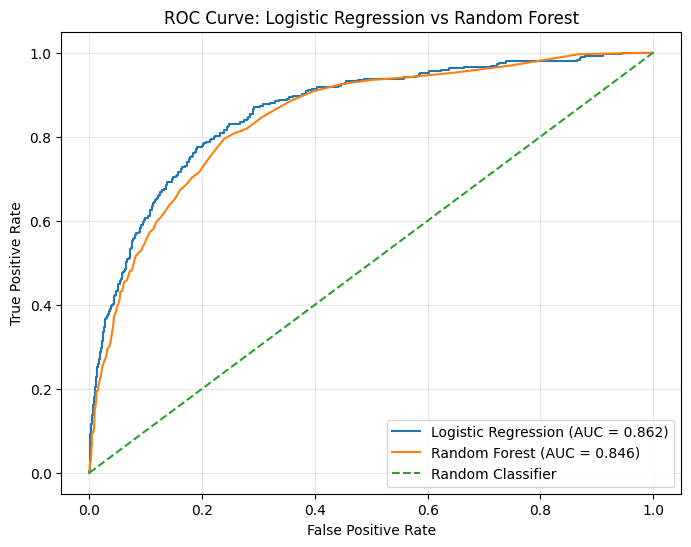

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC curve for Logistic Regression
logistic_fpr, logistic_tpr, _ = roc_curve(y_test, y_pred_proba)
logistic_auc = auc(logistic_fpr, logistic_tpr)

# ROC curve for Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
rf_auc = auc(rf_fpr, rf_tpr)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression vs Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get logistic regression coefficients
coefficients = logistic_model.coef_[0]

# Create a dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient for ranking
coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()

# Sort by absolute coefficient
coef_df = coef_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

# Display top 15 factors
print("Top 15 Factors Influencing Default Prediction")
print("-----------------------------------------------")
print(coef_df.head(15).to_string(index=False))

Top 15 Factors Influencing Default Prediction
-----------------------------------------------
                                        Feature  Coefficient  Absolute_Coefficient
                               num__cibil_score    -0.937306              0.937306
                   cat__collateral_provided_Yes    -0.781479              0.781479
                          num__emi_income_ratio     0.518626              0.518626
                    num__late_payments_last_12m     0.482331              0.482331
            cat__employment_type_Salaried - PSU    -0.406671              0.406671
        cat__employment_type_Salaried - Private    -0.378095              0.378095
cat__employment_type_Self-Employed Professional    -0.351994              0.351994
                         num__loan_income_ratio     0.334706              0.334706
     cat__employment_type_Salaried - Government    -0.290436              0.290436
                             cat__state_Gujarat    -0.266946              0.

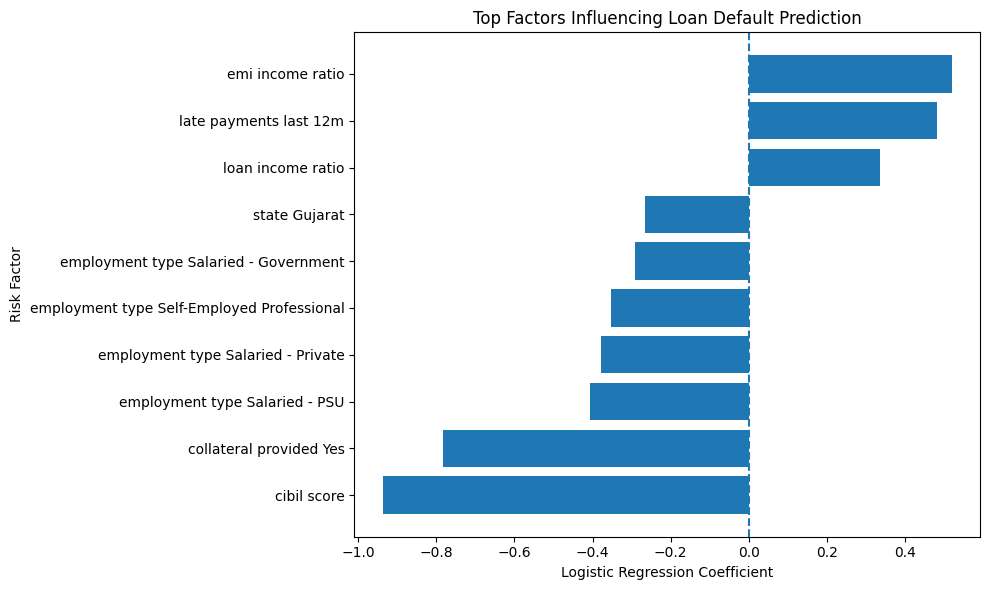

In [ ]:
import matplotlib.pyplot as plt

# Select top 10 factors by absolute coefficient
top_coef = coef_df.head(10).copy()

# Clean feature names for presentation
top_coef["Feature"] = (
    top_coef["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

# Sort for plotting
top_coef = top_coef.sort_values("Coefficient")

plt.figure(figsize=(10, 6))

plt.barh(
    top_coef["Feature"],
    top_coef["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Risk Factor")
plt.title("Top Factors Influencing Loan Default Prediction")

plt.tight_layout()
plt.show()